<a href="https://colab.research.google.com/github/Abdullah-567/Deep-Learning-Tutorials/blob/main/Tutorial_no_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Load MNIST dataset

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


Preprocessing--Normalize images

In [ ]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


One-hot encode labels

In [ ]:
# Convert labels into one-hot encoded vectors
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training labels shape:", y_train.shape)
print("Example label:", y_train[0])

Training labels shape: (60000, 10)
Example label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Visualize MNIST data

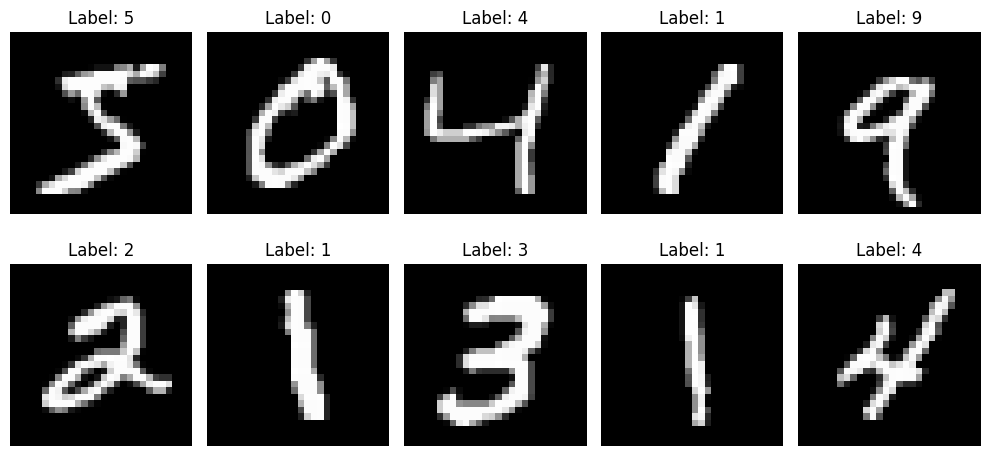

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Build the Original ANN

In [ ]:
# Original ANN model

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [ ]:
model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train the Original Model

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9242 - loss: 0.2605 - val_accuracy: 0.9628 - val_loss: 0.1301
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9676 - loss: 0.1091 - val_accuracy: 0.9688 - val_loss: 0.1051
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9770 - loss: 0.0745 - val_accuracy: 0.9737 - val_loss: 0.0897
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9822 - loss: 0.0560 - val_accuracy: 0.9732 - val_loss: 0.0940
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9863 - loss: 0.0441 - val_accuracy: 0.9717 - val_loss: 0.1041
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9735 - val_loss: 0.0995
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9908 - loss: 0.0280 - val_accuracy: 0.9741 - val_loss: 0.0982
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9915 - loss: 0.0257 - 

Evaluate the model

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.0939987376332283
Test Accuracy: 0.9778000116348267


Plot Training and Validation Accuracy

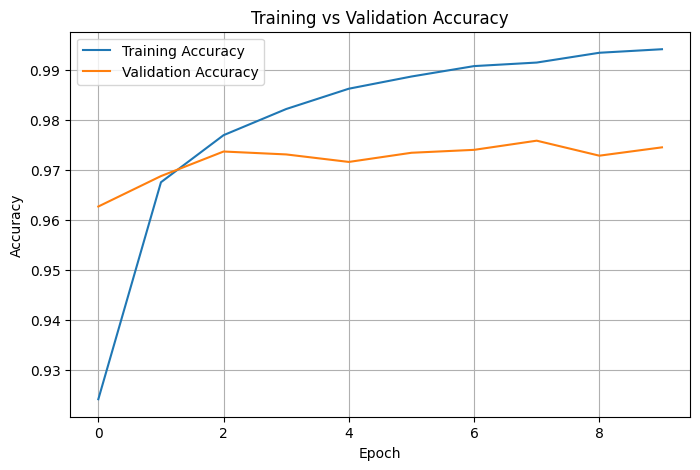

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Plot Loss

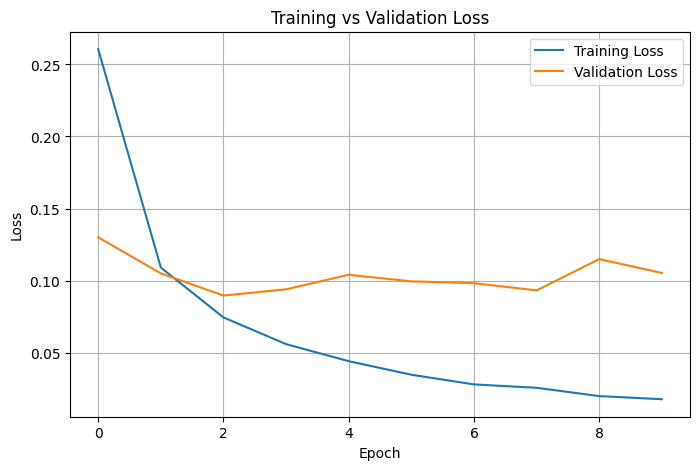

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

Make Predictions

In [ ]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted labels:", predicted_labels[:10])
print("True labels:", true_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted labels: [7 2 1 0 4 1 4 9 5 9]
True labels: [7 2 1 0 4 1 4 9 5 9]


Visualize Predictions

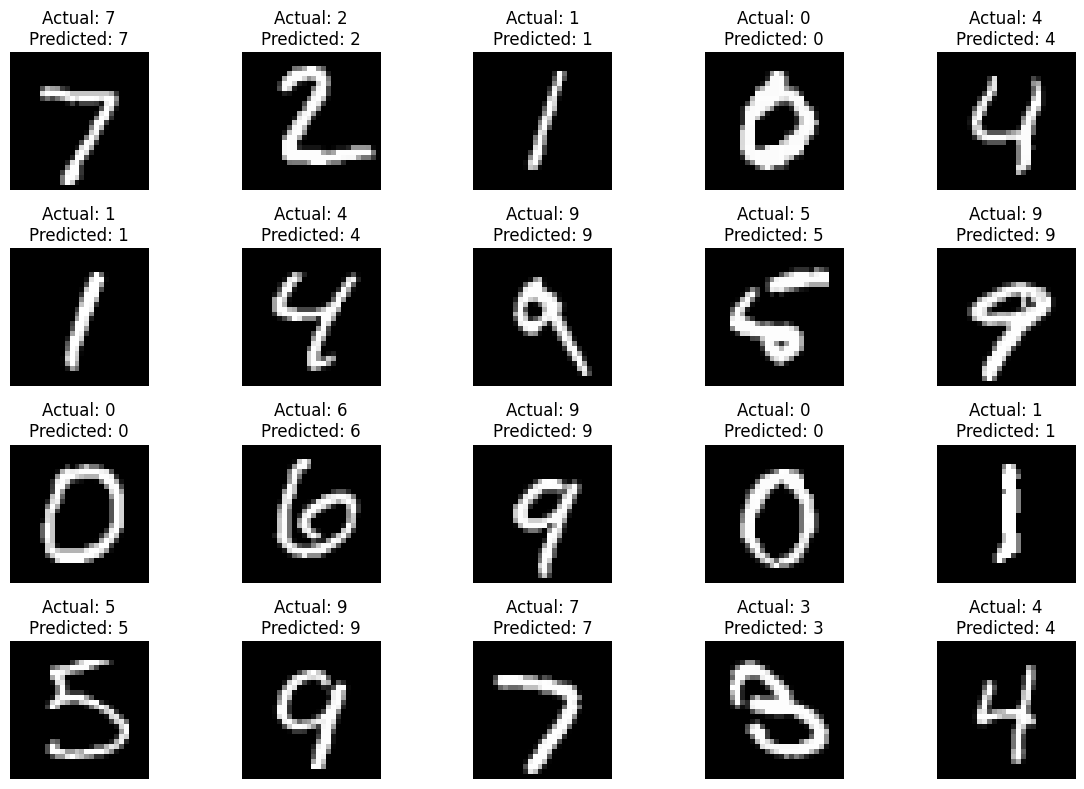

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[i], cmap="gray")

    predicted = predicted_labels[i]
    actual = true_labels[i]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Task** 1 Different Architectures---Function to build models

In [ ]:
def build_model(hidden_layers, activation="relu"):
    model = Sequential()

    # Input layer
    model.add(Flatten(input_shape=(28, 28)))

    # Hidden layers
    for neurons in hidden_layers:
        model.add(Dense(neurons, activation=activation))

    # Output layer
    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Architecture 1

In [ ]:
model_1 = build_model([128, 64], activation="relu")

history_1 = model_1.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

loss_1, accuracy_1 = model_1.evaluate(x_test, y_test, verbose=0)

print("Architecture 1 Test Accuracy:", accuracy_1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9230 - loss: 0.2641 - val_accuracy: 0.9577 - val_loss: 0.1405
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9678 - loss: 0.1109 - val_accuracy: 0.9640 - val_loss: 0.1166
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9762 - loss: 0.0770 - val_accuracy: 0.9663 - val_loss: 0.1072
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9820 - loss: 0.0579 - val_accuracy: 0.9738 - val_loss: 0.0919
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9855 - loss: 0.0445 - val_accuracy: 0.9726 - val_loss: 0.0972
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9883 - loss: 0.0361 - val_accuracy: 0.9712 - val_loss: 0.1010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9899 - loss: 0.0296 - val_accuracy: 0.9712 - val_loss: 0.1152
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9919 - loss: 0.0242 - 

Architecture 2

In [ ]:
model_2 = build_model([128, 64, 32], activation="relu")

history_2 = model_2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

loss_2, accuracy_2 = model_2.evaluate(x_test, y_test, verbose=0)

print("Architecture 2 Test Accuracy:", accuracy_2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9151 - loss: 0.2826 - val_accuracy: 0.9523 - val_loss: 0.1535
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9646 - loss: 0.1159 - val_accuracy: 0.9628 - val_loss: 0.1247
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9738 - loss: 0.0828 - val_accuracy: 0.9660 - val_loss: 0.1083
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9804 - loss: 0.0624 - val_accuracy: 0.9623 - val_loss: 0.1228
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9842 - loss: 0.0507 - val_accuracy: 0.9713 - val_loss: 0.1056
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9865 - loss: 0.0414 - val_accuracy: 0.9722 - val_loss: 0.0979
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9882 - loss: 0.0362 - val_accuracy: 0.9718 - val_loss: 0.1116
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9904 - loss: 0.0293 - 

Architecture 3

In [ ]:
model_3 = build_model([256, 128, 64], activation="relu")

history_3 = model_3.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

loss_3, accuracy_3 = model_3.evaluate(x_test, y_test, verbose=0)

print("Architecture 3 Test Accuracy:", accuracy_3)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9291 - loss: 0.2381 - val_accuracy: 0.9585 - val_loss: 0.1360
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9701 - loss: 0.0980 - val_accuracy: 0.9689 - val_loss: 0.0999
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9789 - loss: 0.0664 - val_accuracy: 0.9717 - val_loss: 0.0977
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9841 - loss: 0.0504 - val_accuracy: 0.9703 - val_loss: 0.1040
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9869 - loss: 0.0398 - val_accuracy: 0.9738 - val_loss: 0.0999
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9889 - loss: 0.0355 - val_accuracy: 0.9793 - val_loss: 0.0856
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9908 - loss: 0.0276 - val_accuracy: 0.9762 - val_loss: 0.0980
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9911 - loss: 0.0

Compare the Architectures

In [ ]:
print("Architecture Comparison")
print("--------------------------------")
print("Original:       128 -> 64      :", accuracy_1)
print("More layers:    128 -> 64 -> 32:", accuracy_2)
print("More neurons:   256 -> 128 -> 64:", accuracy_3)

Architecture Comparison
--------------------------------
Original:       128 -> 64      : 0.9728999733924866
More layers:    128 -> 64 -> 32: 0.9779999852180481
More neurons:   256 -> 128 -> 64: 0.978600025177002


TASK 1B — Activation Functions

In [ ]:
activations = ["relu", "tanh", "sigmoid"]

activation_results = {}

for activation in activations:

    print("\nTraining with:", activation)

    temp_model = build_model(
        [128, 64],
        activation=activation
    )

    temp_history = temp_model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.20,
        verbose=0
    )

    temp_loss, temp_accuracy = temp_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    activation_results[activation] = temp_accuracy

    print("Test Accuracy:", temp_accuracy)


Training with: relu
Test Accuracy: 0.9765999913215637

Training with: tanh
Test Accuracy: 0.968999981880188

Training with: sigmoid
Test Accuracy: 0.9768000245094299


Display activation results

In [ ]:
print("\nActivation Function Comparison")
print("--------------------------------")

for activation, accuracy in activation_results.items():
    print(f"{activation}: {accuracy:.4f}")


Activation Function Comparison
--------------------------------
relu: 0.9766
tanh: 0.9690
sigmoid: 0.9768


Task 2---- Compare Optimizers

In [ ]:
optimizers = {
    "SGD": SGD(),
    "RMSprop": RMSprop(),
    "Adam": Adam()
}

optimizer_results = {}
optimizer_histories = {}

for name, optimizer in optimizers.items():

    print("\nTraining with optimizer:", name)

    temp_model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    temp_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    temp_history = temp_model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.20,
        verbose=0
    )

    test_loss, test_accuracy = temp_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    optimizer_results[name] = test_accuracy
    optimizer_histories[name] = temp_history

    print("Test Accuracy:", test_accuracy)


Training with optimizer: SGD
Test Accuracy: 0.9613000154495239

Training with optimizer: RMSprop
Test Accuracy: 0.9728999733924866

Training with optimizer: Adam
Test Accuracy: 0.9747999906539917


Optimizer comparison

In [ ]:
print("\nOptimizer Comparison")
print("--------------------------------")

for optimizer, accuracy in optimizer_results.items():
    print(f"{optimizer}: {accuracy:.4f}")


Optimizer Comparison
--------------------------------
SGD: 0.9613
RMSprop: 0.9729
Adam: 0.9748


Compare Optimizer Accuracy Curves

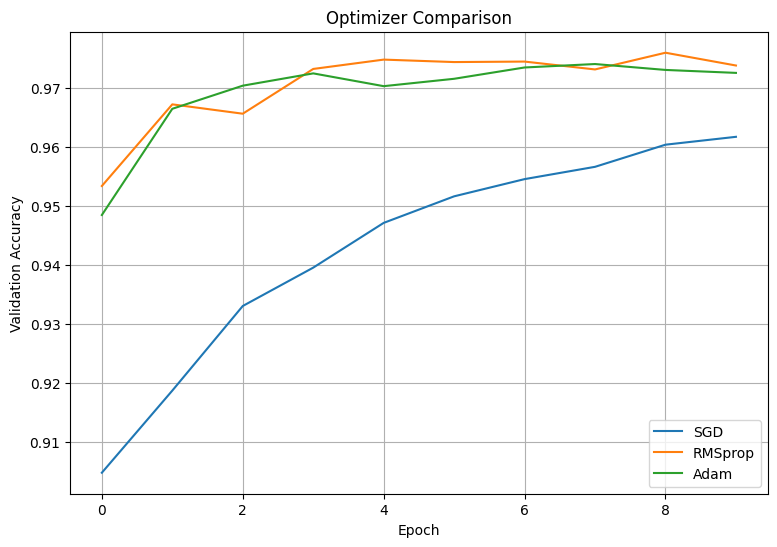

In [ ]:
plt.figure(figsize=(9, 6))

for name, history_data in optimizer_histories.items():
    plt.plot(
        history_data.history["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid(True)

plt.show()

Task 3----- Overfitting and Underfitting

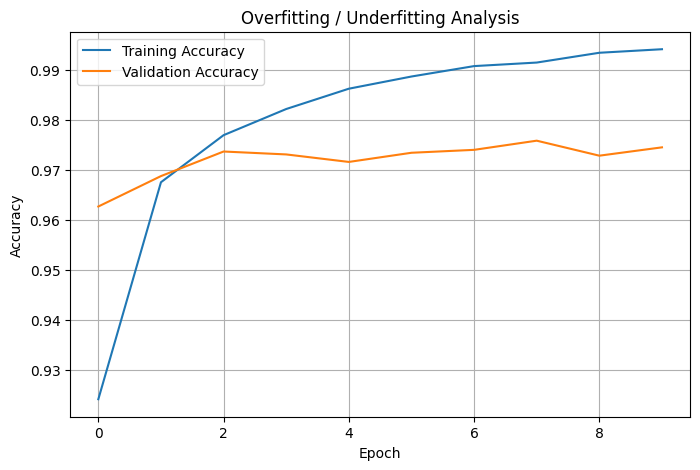

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overfitting / Underfitting Analysis")
plt.legend()
plt.grid(True)

plt.show()

Effect of Number of Epochs

In [ ]:
epoch_values = [5, 10, 20]

epoch_results = {}

for epochs in epoch_values:

    print("\nTraining for", epochs, "epochs")

    temp_model = build_model([128, 64], activation="relu")

    temp_history = temp_model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.20,
        verbose=0
    )

    test_loss, test_accuracy = temp_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    epoch_results[epochs] = test_accuracy

    print("Test Accuracy:", test_accuracy)


Training for 5 epochs
Test Accuracy: 0.9729999899864197

Training for 10 epochs
Test Accuracy: 0.9740999937057495

Training for 20 epochs
Test Accuracy: 0.9794999957084656


In [ ]:
print("\nEpoch Comparison")
print("--------------------------------")

for epochs, accuracy in epoch_results.items():
    print(f"{epochs} epochs: {accuracy:.4f}")


Epoch Comparison
--------------------------------
5 epochs: 0.9730
10 epochs: 0.9741
20 epochs: 0.9795


Early Stopping

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

early_model = build_model([128, 64], activation="relu")

early_history = early_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9239 - loss: 0.2603 - val_accuracy: 0.9594 - val_loss: 0.1304
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9669 - loss: 0.1089 - val_accuracy: 0.9659 - val_loss: 0.1177
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9767 - loss: 0.0751 - val_accuracy: 0.9704 - val_loss: 0.1000
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9821 - loss: 0.0579 - val_accuracy: 0.9707 - val_loss: 0.1002
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9862 - loss: 0.0436 - val_accuracy: 0.9732 - val_loss: 0.0928
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9885 - loss: 0.0360 - val_accuracy: 0.9747 - val_loss: 0.0920
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9909 - loss: 0.0273 - val_accuracy: 0.9725 - val_loss: 0.1104
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9919 - loss: 0.0250 - 

Evaluate Early Stopping model

In [ ]:
early_loss, early_accuracy = early_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Early Stopping Test Loss:", early_loss)
print("Early Stopping Test Accuracy:", early_accuracy)

print(
    "Number of epochs actually completed:",
    len(early_history.history["loss"])
)

Early Stopping Test Loss: 0.1315426528453827
Early Stopping Test Accuracy: 0.9599999785423279
Number of epochs actually completed: 8


Regularization

In [ ]:
regularized_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

regularized_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train regularized model

In [ ]:
regularized_history = regularized_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8688 - loss: 0.4356 - val_accuracy: 0.9517 - val_loss: 0.1595
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9380 - loss: 0.2140 - val_accuracy: 0.9625 - val_loss: 0.1216
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9511 - loss: 0.1684 - val_accuracy: 0.9647 - val_loss: 0.1145
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9570 - loss: 0.1456 - val_accuracy: 0.9731 - val_loss: 0.0956
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9610 - loss: 0.1330 - val_accuracy: 0.9701 - val_loss: 0.0961
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9645 - loss: 0.1192 - val_accuracy: 0.9720 - val_loss: 0.0958
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9664 - loss: 0.1099 - val_accuracy: 0.9735 - val_loss: 0.0901
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9690 - loss: 0.1023 - 

Train regularized model

In [ ]:
regularized_loss, regularized_accuracy = regularized_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Regularized Model Test Loss:", regularized_loss)
print("Regularized Model Test Accuracy:", regularized_accuracy)

Regularized Model Test Loss: 0.07784053683280945
Regularized Model Test Accuracy: 0.9779999852180481


Evaluate regularized model

In [ ]:
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(f"Original Architecture:       {accuracy_1:.4f}")
print(f"More Layers:                 {accuracy_2:.4f}")
print(f"More Neurons:                {accuracy_3:.4f}")

print("\nActivation Functions:")
for activation, accuracy in activation_results.items():
    print(f"{activation}:                    {accuracy:.4f}")

print("\nOptimizers:")
for optimizer, accuracy in optimizer_results.items():
    print(f"{optimizer}:                      {accuracy:.4f}")

print("\nEpochs:")
for epochs, accuracy in epoch_results.items():
    print(f"{epochs} epochs:                   {accuracy:.4f}")

print("\nEarly Stopping:")
print(f"Accuracy:                      {early_accuracy:.4f}")

print("\nRegularization:")
print(f"Dropout Accuracy:              {regularized_accuracy:.4f}")

FINAL RESULTS
Original Architecture:       0.9729
More Layers:                 0.9780
More Neurons:                0.9786

Activation Functions:
relu:                    0.9766
tanh:                    0.9690
sigmoid:                    0.9768

Optimizers:
SGD:                      0.9613
RMSprop:                      0.9729
Adam:                      0.9748

Epochs:
5 epochs:                   0.9730
10 epochs:                   0.9741
20 epochs:                   0.9795

Early Stopping:
Accuracy:                      0.9600

Regularization:
Dropout Accuracy:              0.9780


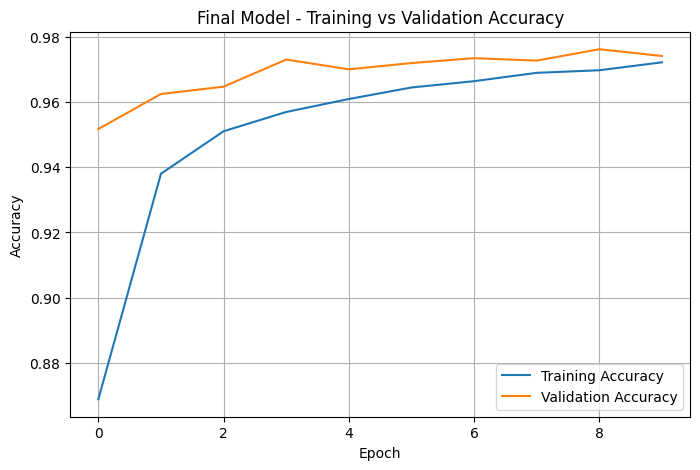

In [ ]:
# Final Improved Model - Training and Validation Curves

plt.figure(figsize=(8, 5))

plt.plot(
    regularized_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    regularized_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model - Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

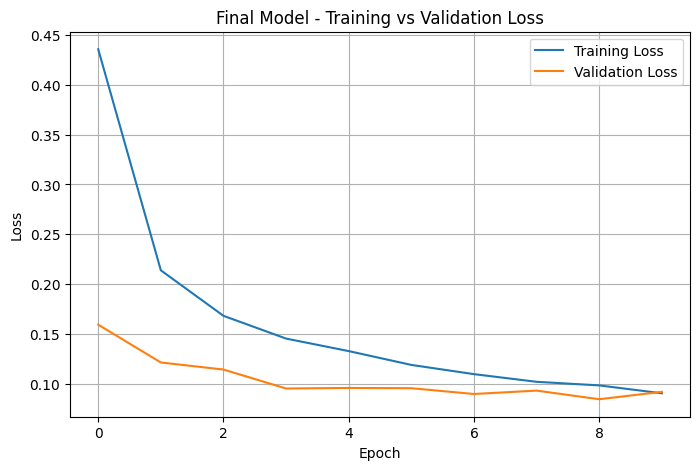

In [ ]:
# Final Improved Model - Loss Curve

plt.figure(figsize=(8, 5))

plt.plot(
    regularized_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    regularized_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model - Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# FINAL IMPROVED MODEL
# Dropout Regularization + Early Stopping

final_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

final_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

final_history = final_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8701 - loss: 0.4325 - val_accuracy: 0.9532 - val_loss: 0.1645
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9378 - loss: 0.2162 - val_accuracy: 0.9647 - val_loss: 0.1217
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9501 - loss: 0.1717 - val_accuracy: 0.9675 - val_loss: 0.1076
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9551 - loss: 0.1489 - val_accuracy: 0.9709 - val_loss: 0.0985
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9626 - loss: 0.1272 - val_accuracy: 0.9721 - val_loss: 0.0960
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9639 - loss: 0.1214 - val_accuracy: 0.9741 - val_loss: 0.0896
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9654 - loss: 0.1124 - val_accuracy: 0.9710 - val_loss: 0.0951
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9686 - loss: 0.1038 -

In [ ]:
# Evaluate Final Improved Model

final_loss, final_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Final Model Test Loss:", final_loss)
print("Final Model Test Accuracy:", final_accuracy)

print(
    "Epochs actually completed:",
    len(final_history.history["loss"])
)

Final Model Test Loss: 0.08402923494577408
Final Model Test Accuracy: 0.9760000109672546
Epochs actually completed: 8


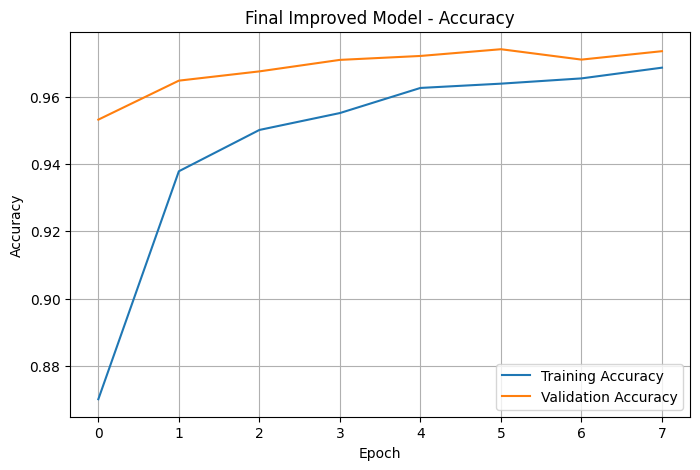

In [ ]:
# FINAL ACCURACY CURVE

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Improved Model - Accuracy")

plt.legend()
plt.grid(True)

plt.show()

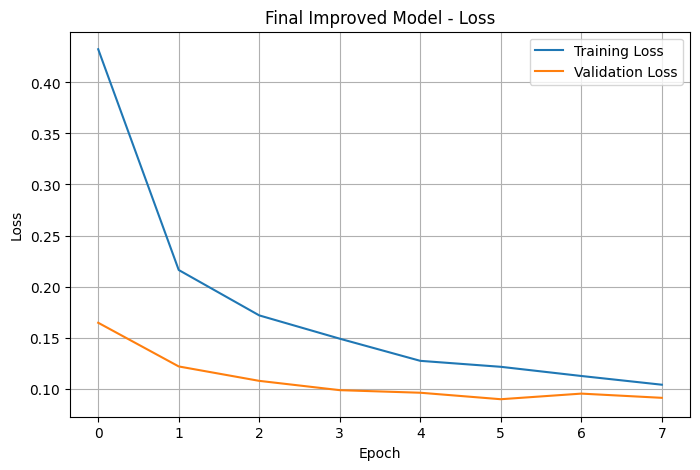

In [ ]:
# FINAL LOSS CURVE

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Improved Model - Loss")

plt.legend()
plt.grid(True)

plt.show()